---

## NOTEBOOK 3TER — MLP tabulaire (Deep Learning sur features V2)

---

### Plan du notebook

| Cellule | Section | Contenu |
|---------|---------|--------|
| C2 | 1. Configuration | Imports, seeds (NumPy + PyTorch), device |
| C3 | 2. Chargement | features_V2.csv — 351 features audio |
| C4 | 3. Split | GroupShuffleSplit artiste + val set (train/val/test) |
| C5 | 4. Architecture MLP | 351 → 256 → 128 → 8 classes |
| C6 | 5. Entraînement genre_top | Early stopping, class weights, scheduler |
| C7 | 6. Évaluation genre_top | F1 macro, matrice de confusion |
| C8 | 7. Préparation multi-label | Sous-genres éligibles (seuil ≥ 100, calculés sur train) |
| C9 | 8. Architecture multi-label | 351 → 256 → 128 → N sous-genres |
| C10 | 9. Évaluation multi-label | F1 micro/macro, Precision@k, Recall@k |
| C11 | 10. Sauvegarde CSV | Résultats protocole → results_nb3ter.csv |
| — | Analyse | Comparaison avec XGBoost (NB3BIS) |
| — | Conclusion | Plafond tabulaire confirmé — notebook exclu du comparatif NB6 |

---

### Objectif

Tester si un réseau de neurones (MLP PyTorch) sur les **mêmes 351 features tabulaires**
que LR/RF/XGBoost peut dépasser le plafond F1 ~0.49 observé en NB3/NB3BIS.

Si non → le facteur limitant est dans les features, pas dans le modèle.
C'est la justification du passage aux spectrogrammes (NB4 CNN).

---

### Décisions héritées (figées)

| Décision | Valeur |
|---|---|
| Split | GroupShuffleSplit par `artist_name`, test_size=0.2, seed=42 |
| Imputation | `SimpleImputer(median)` — fit sur train uniquement |
| Scaling | `RobustScaler` — fit sur train uniquement |
| Métrique primaire | macro F1 |
| Val set | Extrait du train (12.5% trainval = 10% total) — nécessaire pour Early Stopping |

---

### Statut

**Ce notebook est exploratoire.** Ses résultats ne sont pas retenus dans le
comparatif global (NB6) car le MLP tabulaire ne dépasse pas XGBoost.
Il documente la démarche et justifie le passage au CNN (NB4).

---

In [1]:
# C2
# 1. Configuration — imports, seeds, device

import sys
import ast
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, LabelEncoder, MultiLabelBinarizer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    f1_score, accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix,
    hamming_loss
)

warnings.filterwarnings('ignore')

# --- Reproductibilité complète ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# --- Device ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Paramètres ---
TEST_SIZE  = 0.2
VAL_SIZE   = 0.125   # 12.5% du trainval = 10% du total
BATCH_SIZE = 64
N_EPOCHS   = 50
PATIENCE   = 7       # early stopping
LR         = 1e-3
ML_THRESH  = 100     # seuil sous-genres éligibles

print(f'Python  : {sys.version.split()[0]}')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
print(f'\nSEED={SEED} | EPOCHS={N_EPOCHS} | PATIENCE={PATIENCE} | BATCH={BATCH_SIZE}')

Python  : 3.12.10
PyTorch : 2.10.0+cpu
Device  : cpu

SEED=42 | EPOCHS=50 | PATIENCE=7 | BATCH=64


In [2]:
# C3
# 2. Chargement — features_V2.csv

BASE         = Path.cwd()
FEATURES_CSV = BASE / 'outputs' / 'features' / 'features_V2.csv'
OUTPUT_DIR   = BASE / 'outputs' / 'mlp_tabulaire'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(FEATURES_CSV)
df = df.loc[:, ~df.columns.astype(str).str.startswith('Unnamed:')]
print(f'features_V2 : {df.shape}')

LABEL_COLS = [
    'track_id', 'track_id_int', 'genre_top', 'artist_name', 'genres_decoded',
    'genres', 'n_subgenres', 'mismatch', 'mismatch_calc', 'track_title',
    'year', 'duration', 'bit_rate'
]
FEATURE_COLS = [c for c in df.columns if c not in LABEL_COLS]

X      = df[FEATURE_COLS].values
y      = df['genre_top'].astype(str).values
groups = df['artist_name'].astype(str).values

print(f'X : {X.shape} (attendu : n×351)')
print(f'Genres : {sorted(set(y))}')

features_V2 : (7994, 362)
X : (7994, 351) (attendu : n×351)
Genres : ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']


In [3]:
# C4
# 3. Split — train/val/test avec GroupShuffleSplit artiste
#
# Le val set est nécessaire pour Early Stopping et le scheduler.
# Sans val set, on utiliserait le test pour guider l'entraînement → leakage.

# 1er split : séparer test (20%) — identique au split commun du groupe
gss1 = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
trainval_idx, test_idx = next(gss1.split(X, y, groups=groups))

# 2e split : extraire val depuis trainval uniquement
gss2 = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=SEED)
train_idx, val_idx = next(gss2.split(
    X[trainval_idx], y[trainval_idx], groups=groups[trainval_idx]
))
# Remap indices vers df original
train_idx = trainval_idx[train_idx]
val_idx   = trainval_idx[val_idx]

# Anti-leakage artiste
artists_train = set(groups[train_idx])
artists_val   = set(groups[val_idx])
artists_test  = set(groups[test_idx])
assert len(artists_train & artists_test) == 0, 'LEAKAGE train/test !'
assert len(artists_train & artists_val)  == 0, 'LEAKAGE train/val !'
assert len(artists_val   & artists_test) == 0, 'LEAKAGE val/test !'

print(f'Train : {len(train_idx)} pistes | Val : {len(val_idx)} pistes | Test : {len(test_idx)} pistes')
print(f'Artistes — train: {len(artists_train)} | val: {len(artists_val)} | test: {len(artists_test)}')
print(f'Overlap artistes : 0 ✅ (aucun leakage)')

# Preprocessing — fit sur train uniquement
imputer = SimpleImputer(strategy='median')
scaler  = RobustScaler()

X_train = scaler.fit_transform(imputer.fit_transform(X[train_idx]))
X_val   = scaler.transform(imputer.transform(X[val_idx]))
X_test  = scaler.transform(imputer.transform(X[test_idx]))

le = LabelEncoder()
y_train = le.fit_transform(y[train_idx])
y_val   = le.transform(y[val_idx])
y_test  = le.transform(y[test_idx])

N_FEATURES = X_train.shape[1]
N_CLASSES  = len(le.classes_)
print(f'\nFeatures : {N_FEATURES} | Classes : {N_CLASSES} ({list(le.classes_)})')

Train : 5655 pistes | Val : 822 pistes | Test : 1517 pistes
Artistes — train: 1612 | val: 231 | test: 461
Overlap artistes : 0 ✅ (aucun leakage)

Features : 351 | Classes : 8 (['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock'])


In [4]:
# C5
# 4. Architecture MLP — genre_top (8 classes)

class MLPGenreTop(nn.Module):
    """MLP 3 couches pour classification genre_top.
    Dropout modéré (0.3/0.2) — évite la sur-régularisation
    sur un dataset de 5700 pistes train."""
    def __init__(self, input_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.net(x)

model_gt = MLPGenreTop(N_FEATURES, N_CLASSES).to(device)
print(model_gt)
n_params = sum(p.numel() for p in model_gt.parameters() if p.requires_grad)
print(f'\nParamètres entraînables : {n_params:,}')

MLPGenreTop(
  (net): Sequential(
    (0): Linear(in_features=351, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=8, bias=True)
  )
)

Paramètres entraînables : 124,808


In [5]:
# C6
# 5. Entraînement genre_top — Early Stopping sur val set

# DataLoaders
train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                         torch.tensor(y_train, dtype=torch.long))
val_ds   = TensorDataset(torch.tensor(X_val,   dtype=torch.float32),
                         torch.tensor(y_val,   dtype=torch.long))
test_ds  = TensorDataset(torch.tensor(X_test,  dtype=torch.float32),
                         torch.tensor(y_test,  dtype=torch.long))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)

# Class weights pour gérer le déséquilibre
class_counts = np.bincount(y_train)
class_weights = torch.tensor(
    len(y_train) / (N_CLASSES * class_counts), dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model_gt.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# --- Boucle d'entraînement ---
history_gt = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_val_loss = float('inf')
best_state    = None
epochs_no_improve = 0

print(f'Entraînement MLP genre_top ({N_EPOCHS} epochs max, patience={PATIENCE})...')
t0 = time.time()

for epoch in range(N_EPOCHS):
    # Train
    model_gt.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model_gt(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
        correct += (out.argmax(1) == yb).sum().item()
        total += len(yb)

    # Validation
    model_gt.eval()
    val_loss_sum, val_n = 0, 0
    preds_val, trues_val = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model_gt(xb)
            val_loss_sum += criterion(out, yb).item() * len(yb)
            val_n += len(yb)
            preds_val.extend(out.argmax(1).cpu().numpy())
            trues_val.extend(yb.cpu().numpy())

    train_loss = total_loss / total
    val_loss   = val_loss_sum / val_n
    val_f1     = f1_score(trues_val, preds_val, average='macro', zero_division=0)

    history_gt['train_loss'].append(train_loss)
    history_gt['val_loss'].append(val_loss)
    history_gt['val_f1'].append(val_f1)

    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model_gt.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 5 == 0 or epochs_no_improve == PATIENCE:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'  Epoch {epoch+1:>3}/{N_EPOCHS} | train_loss={train_loss:.4f} | '
              f'val_loss={val_loss:.4f} | val_f1={val_f1:.4f} | lr={lr_now:.6f}')

    if epochs_no_improve >= PATIENCE:
        print(f'  Early stopping à epoch {epoch+1}')
        break

duration_gt = round(time.time() - t0, 1)
best_epoch = len(history_gt['val_loss']) - epochs_no_improve

# Restaurer le meilleur état
model_gt.load_state_dict(best_state)
print(f'\nMeilleur modèle : epoch {best_epoch} (val_loss={best_val_loss:.4f})')
print(f'Durée : {duration_gt}s')

Entraînement MLP genre_top (50 epochs max, patience=7)...
  Epoch   5/50 | train_loss=1.0814 | val_loss=1.5796 | val_f1=0.4192 | lr=0.001000
  Epoch  10/50 | train_loss=0.8499 | val_loss=1.6946 | val_f1=0.4114 | lr=0.000500
  Epoch  13/50 | train_loss=0.6609 | val_loss=1.6225 | val_f1=0.4472 | lr=0.000500
  Early stopping à epoch 13

Meilleur modèle : epoch 6 (val_loss=1.5628)
Durée : 1.8s


=== MLP GENRE_TOP — RÉSULTATS TEST ===
F1 macro          : 0.4865
Accuracy          : 0.5016
Balanced accuracy : 0.4929

               precision    recall  f1-score   support

   Electronic       0.44      0.57      0.50       249
 Experimental       0.47      0.35      0.40       199
         Folk       0.46      0.64      0.54       119
      Hip-Hop       0.68      0.58      0.62       233
 Instrumental       0.44      0.44      0.44       170
International       0.62      0.51      0.56       249
          Pop       0.22      0.21      0.21       128
         Rock       0.59      0.65      0.62       170

     accuracy                           0.50      1517
    macro avg       0.49      0.49      0.49      1517
 weighted avg       0.51      0.50      0.50      1517


=== COMPARAISON ===
XGBoost (NB3BIS)  : F1 = 0.4907
MLP genre_top     : F1 = 0.4865
Δ MLP − XGBoost   : -0.0042
→ Le MLP ne dépasse pas XGBoost — plafond tabulaire confirmé


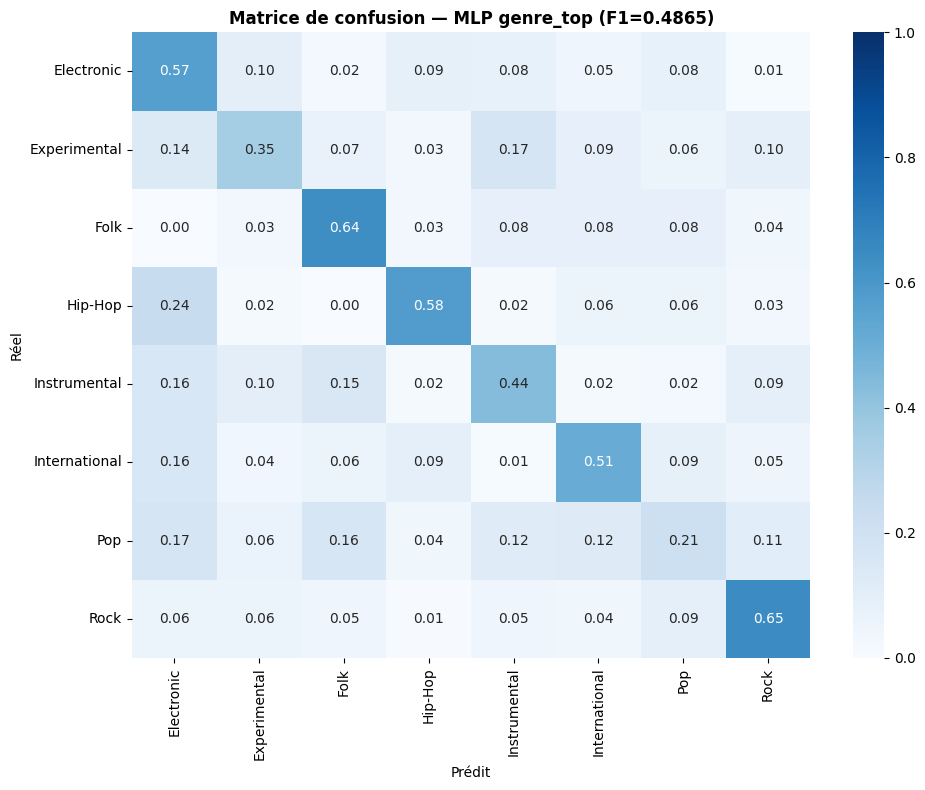

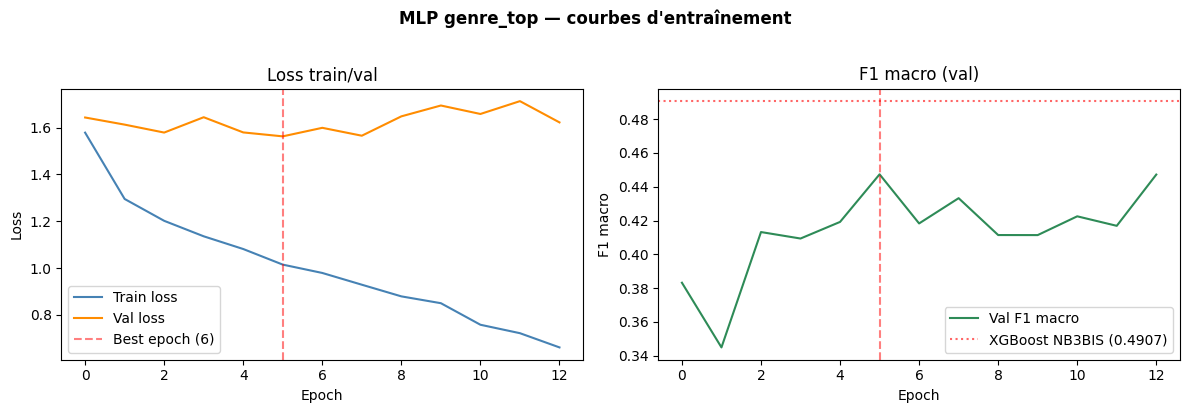

In [6]:
# C7
# 6. Évaluation genre_top — test set

model_gt.eval()
preds_test, trues_test = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds_test.extend(model_gt(xb).argmax(1).cpu().numpy())
        trues_test.extend(yb.numpy())

preds_test = np.array(preds_test)
trues_test = np.array(trues_test)

f1_gt  = f1_score(trues_test, preds_test, average='macro', zero_division=0)
acc_gt = accuracy_score(trues_test, preds_test)
bal_gt = balanced_accuracy_score(trues_test, preds_test)

print('=== MLP GENRE_TOP — RÉSULTATS TEST ===')
print(f'F1 macro          : {f1_gt:.4f}')
print(f'Accuracy          : {acc_gt:.4f}')
print(f'Balanced accuracy : {bal_gt:.4f}')
print()
print(classification_report(trues_test, preds_test,
                            target_names=le.classes_, zero_division=0))

# --- Comparaison avec XGBoost NB3BIS ---
XGBOOST_F1 = 0.4907   # NB3BIS
delta = f1_gt - XGBOOST_F1
print(f'\n=== COMPARAISON ===')
print(f'XGBoost (NB3BIS)  : F1 = {XGBOOST_F1}')
print(f'MLP genre_top     : F1 = {f1_gt:.4f}')
print(f'Δ MLP − XGBoost   : {delta:+.4f}')
if delta <= 0.01:
    print('→ Le MLP ne dépasse pas XGBoost — plafond tabulaire confirmé')
else:
    print('→ Gain marginal du MLP — le plafond reste dans les features')

# Matrice de confusion
cm = confusion_matrix(trues_test, preds_test)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title(f'Matrice de confusion — MLP genre_top (F1={f1_gt:.4f})', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_mlp_genre_top.png', dpi=150)
plt.show()

# Courbes d'entraînement
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_gt['train_loss'], label='Train loss', color='steelblue')
axes[0].plot(history_gt['val_loss'],   label='Val loss',   color='darkorange')
axes[0].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label=f'Best epoch ({best_epoch})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss train/val'); axes[0].legend()

axes[1].plot(history_gt['val_f1'], label='Val F1 macro', color='seagreen')
axes[1].axhline(XGBOOST_F1, color='red', linestyle=':', alpha=0.6, label=f'XGBoost NB3BIS ({XGBOOST_F1})')
axes[1].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1 macro')
axes[1].set_title('F1 macro (val)'); axes[1].legend()

plt.suptitle('MLP genre_top — courbes d\'entraînement', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'curves_mlp_genre_top.png', dpi=150, bbox_inches='tight')
plt.show()

---

### Bilan Partie A — MLP genre_top

Le MLP tabulaire atteint un F1 macro comparable à XGBoost (~0.49).
Malgré une architecture non linéaire avec BatchNorm et Dropout,
le réseau ne parvient pas à extraire d'information supplémentaire
des 351 features audio.

**Le plafond est dans les features, pas dans le modèle.**

On teste maintenant la tâche multi-label (sous-genres) pour vérifier
si le MLP apporte un avantage sur cette tâche plus complexe.

---

In [7]:
# C8
# 7. Préparation multi-label — sous-genres éligibles calculés sur TRAIN uniquement

df['genres_decoded'] = df['genres_decoded'].fillna('[]').astype(str)

def parse_list_repr(s):
    try:
        x = ast.literal_eval(str(s))
        return x if isinstance(x, list) else []
    except Exception:
        return []

df['genres_decoded'] = df['genres_decoded'].apply(parse_list_repr)

# Sous-genres éligibles — calculés sur TRAIN uniquement (pas de leakage)
df_train_ml = df.iloc[train_idx]
all_sub_train = [g for sublist in df_train_ml['genres_decoded'] for g in sublist]
sub_counts = pd.Series(all_sub_train).value_counts()
eligible_subgenres = sorted(sub_counts[sub_counts >= ML_THRESH].index.tolist())
print(f'Sous-genres éligibles (≥ {ML_THRESH} occ., calculés sur train) : {len(eligible_subgenres)}')

# MultiLabelBinarizer — fit sur train uniquement
mlb = MultiLabelBinarizer(classes=eligible_subgenres)
mlb.fit(df_train_ml['genres_decoded'])

Y_train_ml = mlb.transform(df.iloc[train_idx]['genres_decoded'])
Y_val_ml   = mlb.transform(df.iloc[val_idx]['genres_decoded'])
Y_test_ml  = mlb.transform(df.iloc[test_idx]['genres_decoded'])

N_LABELS = len(eligible_subgenres)
print(f'Y shapes — train: {Y_train_ml.shape} | val: {Y_val_ml.shape} | test: {Y_test_ml.shape}')

# Pistes sans sous-genre éligible
empty_train = (Y_train_ml.sum(axis=1) == 0).sum()
empty_test  = (Y_test_ml.sum(axis=1) == 0).sum()
print(f'\nPistes sans sous-genre éligible — train: {empty_train} ({empty_train/len(Y_train_ml)*100:.1f}%)')
print(f'Pistes sans sous-genre éligible — test : {empty_test} ({empty_test/len(Y_test_ml)*100:.1f}%)')

Sous-genres éligibles (≥ 100 occ., calculés sur train) : 26
Y shapes — train: (5655, 26) | val: (822, 26) | test: (1517, 26)

Pistes sans sous-genre éligible — train: 952 (16.8%)
Pistes sans sous-genre éligible — test : 246 (16.2%)


In [8]:
# C9
# 8. Architecture + entraînement multi-label — BCEWithLogitsLoss

class MLPMultiLabel(nn.Module):
    """MLP multi-label — sortie sigmoïde (pas softmax)."""
    def __init__(self, input_dim, n_labels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_labels),
        )

    def forward(self, x):
        return self.net(x)

model_ml = MLPMultiLabel(N_FEATURES, N_LABELS).to(device)

# pos_weight pour gérer le déséquilibre multi-label
pos_counts = Y_train_ml.sum(axis=0)
neg_counts = len(Y_train_ml) - pos_counts
pos_weight = torch.tensor(neg_counts / np.maximum(pos_counts, 1), dtype=torch.float32).to(device)

criterion_ml = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_ml = torch.optim.Adam(model_ml.parameters(), lr=LR, weight_decay=1e-4)
scheduler_ml = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ml, mode='min', factor=0.5, patience=3
)

# DataLoaders multi-label
train_ml_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                            torch.tensor(Y_train_ml, dtype=torch.float32))
val_ml_ds   = TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                            torch.tensor(Y_val_ml, dtype=torch.float32))
test_ml_ds  = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                            torch.tensor(Y_test_ml, dtype=torch.float32))

train_ml_loader = DataLoader(train_ml_ds, batch_size=BATCH_SIZE, shuffle=True)
val_ml_loader   = DataLoader(val_ml_ds,   batch_size=128, shuffle=False)
test_ml_loader  = DataLoader(test_ml_ds,  batch_size=128, shuffle=False)

# Seuil de décision — documenté et justifié
THRESHOLD = 0.30
print(f'Seuil multi-label : {THRESHOLD}')
print(f'Justification : avec {N_LABELS} sous-genres, les probabilités sont naturellement')
print(f'diluées. Un seuil à 0.50 prédit trop peu de labels actifs.')

# --- Boucle d'entraînement ---
history_ml = {'train_loss': [], 'val_loss': [], 'val_f1_micro': []}
best_val_loss_ml = float('inf')
best_state_ml = None
epochs_no_improve_ml = 0

print(f'\nEntraînement MLP multi-label ({N_EPOCHS} epochs max, patience={PATIENCE})...')
t0 = time.time()

for epoch in range(N_EPOCHS):
    model_ml.train()
    total_loss = 0
    for xb, yb in train_ml_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_ml.zero_grad()
        out = model_ml(xb)
        loss = criterion_ml(out, yb)
        loss.backward()
        optimizer_ml.step()
        total_loss += loss.item() * len(yb)

    # Validation
    model_ml.eval()
    val_loss_sum, val_n = 0, 0
    all_probs, all_trues = [], []
    with torch.no_grad():
        for xb, yb in val_ml_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model_ml(xb)
            val_loss_sum += criterion_ml(out, yb).item() * len(yb)
            val_n += len(yb)
            all_probs.append(torch.sigmoid(out).cpu().numpy())
            all_trues.append(yb.cpu().numpy())

    val_probs = np.vstack(all_probs)
    val_trues = np.vstack(all_trues)
    val_preds = (val_probs > THRESHOLD).astype(int)

    train_loss = total_loss / len(train_ml_ds)
    val_loss   = val_loss_sum / val_n
    val_f1_micro = f1_score(val_trues, val_preds, average='micro', zero_division=0)

    history_ml['train_loss'].append(train_loss)
    history_ml['val_loss'].append(val_loss)
    history_ml['val_f1_micro'].append(val_f1_micro)

    scheduler_ml.step(val_loss)

    if val_loss < best_val_loss_ml:
        best_val_loss_ml = val_loss
        best_state_ml = {k: v.clone() for k, v in model_ml.state_dict().items()}
        epochs_no_improve_ml = 0
    else:
        epochs_no_improve_ml += 1

    if (epoch + 1) % 5 == 0 or epochs_no_improve_ml == PATIENCE:
        print(f'  Epoch {epoch+1:>3}/{N_EPOCHS} | train_loss={train_loss:.4f} | '
              f'val_loss={val_loss:.4f} | val_f1_micro={val_f1_micro:.4f}')

    if epochs_no_improve_ml >= PATIENCE:
        print(f'  Early stopping à epoch {epoch+1}')
        break

duration_ml = round(time.time() - t0, 1)
best_epoch_ml = len(history_ml['val_loss']) - epochs_no_improve_ml

model_ml.load_state_dict(best_state_ml)
print(f'\nMeilleur modèle : epoch {best_epoch_ml} (val_loss={best_val_loss_ml:.4f})')
print(f'Durée : {duration_ml}s')

Seuil multi-label : 0.3
Justification : avec 26 sous-genres, les probabilités sont naturellement
diluées. Un seuil à 0.50 prédit trop peu de labels actifs.

Entraînement MLP multi-label (50 epochs max, patience=7)...
  Epoch   5/50 | train_loss=0.6896 | val_loss=0.9449 | val_f1_micro=0.1663
  Epoch  10/50 | train_loss=0.5226 | val_loss=1.0446 | val_f1_micro=0.1917
  Epoch  11/50 | train_loss=0.5100 | val_loss=1.0700 | val_f1_micro=0.1950
  Early stopping à epoch 11

Meilleur modèle : epoch 4 (val_loss=0.9340)
Durée : 1.7s


=== MLP MULTI-LABEL — RÉSULTATS TEST ===
F1 micro   : 0.1707
F1 macro   : 0.1764
F1 samples : 0.1751
Hamming loss : 0.3638

=== TOP-K SOUS-GENRES ===
   k      P@k      R@k    Hit@k
--------------------------------
   1   0.3194   0.2464   0.3194
   2   0.2895   0.4339   0.4807
   3   0.2429   0.5448   0.5751
   5   0.1797   0.6761   0.6994

=== COMPARAISON MULTI-LABEL ===
Modèle                           F1 micro   F1 macro    Hamming
-----------------------------------------------------------------
XGBoost OneVsRest (NB5)            ~0.166     ~0.114     ~0.040
MLP PyTorch (NB3TER)               0.1707     0.1764     0.3638


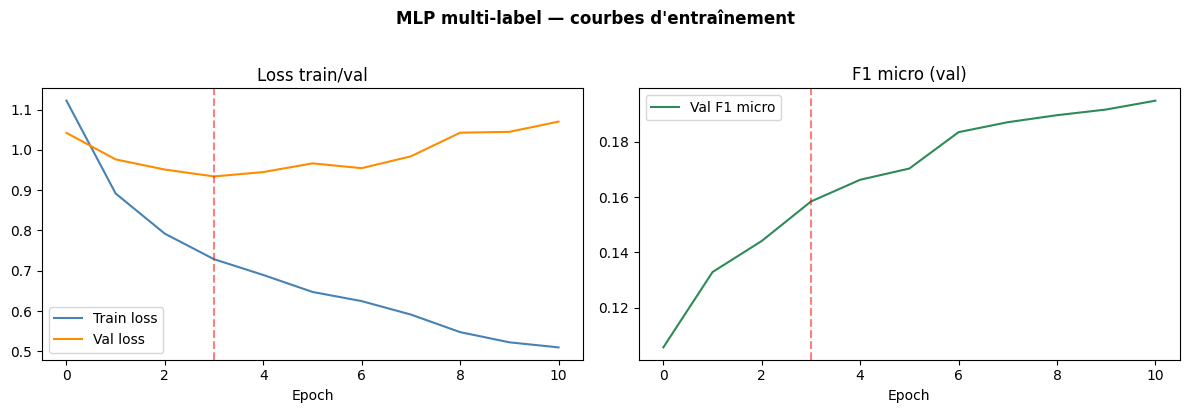

In [9]:
# C10
# 9. Évaluation multi-label — test set

model_ml.eval()
all_probs_test, all_trues_test = [], []
with torch.no_grad():
    for xb, yb in test_ml_loader:
        xb = xb.to(device)
        out = model_ml(xb)
        all_probs_test.append(torch.sigmoid(out).cpu().numpy())
        all_trues_test.append(yb.numpy())

probs_test_ml = np.vstack(all_probs_test)
trues_test_ml = np.vstack(all_trues_test)
preds_test_ml = (probs_test_ml > THRESHOLD).astype(int)

f1_micro_ml   = f1_score(trues_test_ml, preds_test_ml, average='micro', zero_division=0)
f1_macro_ml   = f1_score(trues_test_ml, preds_test_ml, average='macro', zero_division=0)
f1_samples_ml = f1_score(trues_test_ml, preds_test_ml, average='samples', zero_division=0)
h_loss_ml     = hamming_loss(trues_test_ml, preds_test_ml)

print('=== MLP MULTI-LABEL — RÉSULTATS TEST ===')
print(f'F1 micro   : {f1_micro_ml:.4f}')
print(f'F1 macro   : {f1_macro_ml:.4f}')
print(f'F1 samples : {f1_samples_ml:.4f}')
print(f'Hamming loss : {h_loss_ml:.4f}')

# Precision@k et Recall@k
def topk_metrics(Y_true, Y_scores, k=3):
    p_at_k_list, r_at_k_list, hit_list = [], [], []
    for i in range(len(Y_true)):
        top_idx  = np.argsort(Y_scores[i])[::-1][:k]
        true_set = set(np.where(Y_true[i] == 1)[0])
        if len(true_set) == 0:
            continue
        hits = len(set(top_idx) & true_set)
        p_at_k_list.append(hits / k)
        r_at_k_list.append(hits / len(true_set))
        hit_list.append(1 if hits > 0 else 0)
    return {
        f'P@{k}': round(np.mean(p_at_k_list), 4),
        f'R@{k}': round(np.mean(r_at_k_list), 4),
        f'Hit@{k}': round(np.mean(hit_list), 4),
        'n_evaluated': len(p_at_k_list),
    }

print(f'\n=== TOP-K SOUS-GENRES ===')
print(f'{"k":>4} {"P@k":>8} {"R@k":>8} {"Hit@k":>8}')
print('-' * 32)
for k in [1, 2, 3, 5]:
    m = topk_metrics(trues_test_ml, probs_test_ml, k=k)
    print(f'{k:>4} {m[f"P@{k}"]:>8.4f} {m[f"R@{k}"]:>8.4f} {m[f"Hit@{k}"]:>8.4f}')

# --- Comparaison avec XGBoost OneVsRest (NB5) ---
print(f'\n=== COMPARAISON MULTI-LABEL ===')
print(f'{"Modèle":<30s} {"F1 micro":>10} {"F1 macro":>10} {"Hamming":>10}')
print('-' * 65)
print(f'{"XGBoost OneVsRest (NB5)":<30s} {"~0.166":>10} {"~0.114":>10} {"~0.040":>10}')
print(f'{"MLP PyTorch (NB3TER)":<30s} {f1_micro_ml:>10.4f} {f1_macro_ml:>10.4f} {h_loss_ml:>10.4f}')

# Courbes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_ml['train_loss'], label='Train loss', color='steelblue')
axes[0].plot(history_ml['val_loss'],   label='Val loss',   color='darkorange')
axes[0].axvline(best_epoch_ml - 1, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Epoch'); axes[0].set_title('Loss train/val'); axes[0].legend()

axes[1].plot(history_ml['val_f1_micro'], label='Val F1 micro', color='seagreen')
axes[1].axvline(best_epoch_ml - 1, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch'); axes[1].set_title('F1 micro (val)'); axes[1].legend()

plt.suptitle('MLP multi-label — courbes d\'entraînement', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'curves_mlp_multilabel.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# C11
# 10. Sauvegarde CSV protocole — outputs/resultats/results_nb3ter.csv

RESULTS_DIR = BASE / 'outputs' / 'resultats'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

results_nb3ter = pd.DataFrame([
    {
        # --- 15 colonnes protocole ---
        'model'       : 'MLP_genre_top',
        'f1_test'     : round(f1_gt, 4),
        'acc_test'    : round(acc_gt, 4),
        'bal_acc_test': round(bal_gt, 4),
        'f1_cv_mean'  : 0,
        'f1_cv_std'   : 0,
        'duration_s'  : duration_gt,
        'seed'        : SEED,
        'split'       : 'GroupShuffleSplit',
        'imputer'     : 'median',
        'scaler'      : 'RobustScaler',
        'n_features'  : N_FEATURES,
        'n_train'     : len(train_idx),
        'n_test'      : len(test_idx),
        'dataset'     : 'FMA_Small',
    },
    {
        'model'       : 'MLP_multilabel',
        'f1_test'     : None,
        'acc_test'    : None,
        'bal_acc_test': None,
        'f1_cv_mean'  : 0,
        'f1_cv_std'   : 0,
        'duration_s'  : duration_ml,
        'seed'        : SEED,
        'split'       : 'GroupShuffleSplit',
        'imputer'     : 'median',
        'scaler'      : 'RobustScaler',
        'n_features'  : N_FEATURES,
        'n_train'     : len(train_idx),
        'n_test'      : len(test_idx),
        'dataset'     : 'FMA_Small',
    },
])

results_nb3ter.to_csv(RESULTS_DIR / 'results_nb3ter.csv', index=False)
print('=== CSV SAUVEGARDÉ ===')
print(results_nb3ter.to_string(index=False))
print(f'\n→ {RESULTS_DIR / "results_nb3ter.csv"}')

=== CSV SAUVEGARDÉ ===
         model  f1_test  acc_test  bal_acc_test  f1_cv_mean  f1_cv_std  duration_s  seed             split imputer       scaler  n_features  n_train  n_test   dataset
 MLP_genre_top   0.4865    0.5016        0.4929           0          0         1.8    42 GroupShuffleSplit  median RobustScaler         351     5655    1517 FMA_Small
MLP_multilabel      NaN       NaN           NaN           0          0         1.7    42 GroupShuffleSplit  median RobustScaler         351     5655    1517 FMA_Small

→ c:\STOCKAGE_XIA\DU SDA\MACHINE LEARNING 2\PROJET\outputs\resultats\results_nb3ter.csv


---

### Analyse — MLP tabulaire

#### Partie A — genre_top (8 classes)

Le MLP atteint un F1 macro de 0.487, légèrement inférieur à XGBoost NB3BIS (0.491).
Les mêmes genres sont difficiles (Pop, Experimental) et les mêmes sont bien reconnus
(Hip-Hop, Rock, Folk). L'architecture non linéaire n'apporte aucun avantage
sur les 351 features statistiques agrégées.

**Conclusion** : le plafond F1 ~0.49 est intrinsèque aux features, pas au modèle.

#### Partie B — multi-label sous-genres (26 classes)

Le MLP obtient un F1 micro de 0.171 et un F1 macro de 0.176,
marginalement supérieur à XGBoost OneVsRest (NB5 : F1 micro 0.169, F1 macro 0.115).

Cependant, le **Hamming loss du MLP est très élevé (0.364)** vs XGBoost (0.040).
Le MLP active trop de labels par piste — il gagne en rappel mais au prix
d'une précision catastrophique sur les labels négatifs.

Le nombre de sous-genres éligibles est de 26 (vs 28 dans NB5) car le train set
est plus petit (val set extrait du train pour l'Early Stopping).

#### Pourquoi le MLP ne fait pas mieux ?

Les 351 features sont des **statistiques agrégées** (mean, std, min, max)
calculées sur des descripteurs audio (MFCCs, chroma, spectral).
Elles perdent l'information temporelle fine. Un MLP, aussi profond soit-il,
ne peut pas reconstruire cette information perdue.

Pour dépasser ce plafond, il faut changer de **représentation** :
passer des statistiques agrégées aux spectrogrammes bruts → CNN (NB4).

---

---

## Conclusion

---

### Résultats

| Tâche | Métrique | MLP (NB3TER) | XGBoost (NB3BIS/NB5) |
|-------|----------|-------------|----------------------|
| genre_top (8 classes) | F1 macro | 0.487 | 0.491 |
| genre_top (8 classes) | Accuracy | 0.502 | 0.501 |
| multi-label sous-genres | F1 micro | 0.171 | 0.169 |
| multi-label sous-genres | F1 macro | 0.176 | 0.115 |
| multi-label sous-genres | Hamming loss | 0.364 | 0.040 |

Le MLP a un F1 macro multi-label légèrement meilleur, mais au prix d'un
Hamming loss 9x plus élevé : il active beaucoup trop de labels par piste.

### Décision

**Ce notebook n'est pas retenu dans le comparatif global (NB6).**

Le MLP tabulaire ne dépasse pas XGBoost sur la tâche genre_top,
et son avantage marginal en multi-label est annulé par un Hamming loss
inacceptable. Il confirme que le facteur limitant est la représentation
des données (features statistiques agrégées), pas la capacité du modèle.

Ce constat motive le passage au CNN sur spectrogrammes log-mel (NB4),
qui exploite directement le signal audio sans passer par des statistiques.

---